# MongoDB Atlas `sample_airbnb`

Este notebook contiene **10 preguntas con su respuesta** (calculada automáticamente) sobre el dataset de ejemplo de MongoDB Atlas:  
**`sample_airbnb.listingsAndReviews`**.

> **Qué necesitas**: una conexión a un clúster de MongoDB Atlas donde tengas habilitado el sample dataset (o cualquier MongoDB con esa DB).  
> **Seguridad**: no pegues credenciales en repos públicos. Usa variables de entorno o secretos del notebook.

---

## Dataset
Colección principal: `sample_airbnb.listingsAndReviews`

Campos habituales (pueden variar/estar incompletos):
- `price`, `property_type`, `room_type`, `bedrooms`, `beds`, `amenities`
- `review_scores.review_scores_rating`, `number_of_reviews`
- `host.host_is_superhost`, `host.host_response_rate`
- `address.market`, `address.country`, `address.suburb`, `address.location.coordinates` (lon/lat)

In [1]:
# Si ejecutas en un entorno nuevo, instala dependencias
# (puedes comentar esta celda si ya las tienes)
!pip -q install pymongo dnspython pandas numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Conexión a MongoDB Atlas

1. En Atlas: **Database Deployments → Connect → Connect your application** y copia el URI.
2. Reemplaza el placeholder `MONGODB_URI`.
3. Asegúrate de tener acceso en **Network Access** (tu IP) y un usuario con permisos de lectura.

> Si ya tienes el dataset sample cargado en tu clúster, la DB se llama `sample_airbnb`.

In [ ]:
import certifi
from pymongo.mongo_client import MongoClient
from pymongo.server_api import ServerApi
import pandas as pd
import numpy as np

# REEMPLAZA ESTO CON TU URI REAL
uri = ""
# Create a new client and connect to the server
client = MongoClient(uri, server_api=ServerApi('1'))

db = client["sample_airbnb"]
col = db["listingsAndReviews"]
# Send a ping to confirm a successful connection
try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
except Exception as e:
    print(e)

Pinged your deployment. You successfully connected to MongoDB!


## Helpers

- Convertimos `price` a float (en el sample suele venir como número/Decimal128; a veces como string).
- Función para ejecutar `aggregate` y devolver `DataFrame`.

In [2]:
from bson.decimal128 import Decimal128

def to_float(x):
    if x is None:
        return np.nan
    if isinstance(x, Decimal128):
        return float(x.to_decimal())
    try:
        return float(x)
    except Exception:
        return np.nan

def agg_df(pipeline, limit=None):
    """Ejecuta un pipeline de agregación y devuelve un DataFrame de Pandas"""
    cur = col.aggregate(pipeline, allowDiskUse=True)
    data = list(cur)
    
    # Procesar data para convertir Decimal128 a float si es necesario en las columnas de precio
    for doc in data:
        for k, v in doc.items():
            if isinstance(v, Decimal128):
                doc[k] = float(v.to_decimal())
                
    if limit is not None:
        data = data[:limit]
    return pd.DataFrame(data)

def pretty(df, n=10):
    # Helper: muestra df y ajusta columnas si existen
    if len(df) > n:
        return df.head(n)
    return df

## 1) ¿Cuántos alojamientos (listings) hay en la colección y cuántos hosts únicos?

**Respuesta:** el total de documentos representa listings. Para hosts únicos usamos `host.host_id`.

In [11]:
# Contamos todos los documentos (listings) de la colección
total_listings = col.count_documents({})

# Usamos .distinct() para obtener todos los IDs de host únicos y medimos la longitud de esa lista
unique_hosts = len(col.distinct("host.host_id"))

print(f"Total listings: {total_listings}")
print(f"Hosts únicos: {unique_hosts}")

Total listings: 5555
Hosts únicos: 5104


## 2) ¿Cuáles son los 10 *markets* (ciudades/mercados) con más alojamientos?

Usamos `address.market`. (Hay valores vacíos; los filtramos.)

In [12]:
pipeline = [
    {"$match": {"address.market": {"$ne": ""}}},  # 1. Filtramos mercados vacíos
    {"$group": {"_id": "$address.market", "n": {"$sum": 1}}}, # 2. Agrupamos por market y contamos
    {"$sort": {"n": -1}},  # 3. Ordenamos de mayor a menor
    {"$limit": 10},        # 4. Nos quedamos solo con los 10 primeros
    {"$project": {"market": "$_id", "n": 1, "_id": 0}} # 5. Renombramos '_id' a 'market' para que quede bonito
]

# Ejecutamos la agregación usando la función 'agg_df' definida en los helpers
df_markets = agg_df(pipeline)

# Mostramos el resultado
pretty(df_markets)

,n,market
0,660,Istanbul
1,648,Montreal
2,632,Barcelona
3,619,Hong Kong
4,609,Sydney
5,607,New York
6,603,Rio De Janeiro
7,554,Porto
8,253,Oahu
9,153,Maui


## 3) ¿Cuál es el precio medio y mediano por *market* (Top 10 por número de listings)?

En MongoDB, la mediana no es directa en versiones antiguas. Aquí:
- Calculamos **media** en MongoDB.
- Para la **mediana**, traemos precios y calculamos en pandas para los top markets.

> Nota: El campo `price` puede venir como `Decimal128` o numérico.

In [13]:
# 1. Primero obtenemos la lista de los 10 mercados con más alojamientos
pipeline_top10 = [
    {"$match": {"address.market": {"$ne": ""}}},
    {"$group": {"_id": "$address.market", "n": {"$sum": 1}}},
    {"$sort": {"n": -1}},
    {"$limit": 10}
]

# Sacamos la lista de nombres (ej: ['Istanbul', 'Montreal', ...])
top_markets_list = [doc["_id"] for doc in col.aggregate(pipeline_top10)]

# 2. Traemos los precios solo de esos mercados
pipeline_precios = [
    {"$match": {
        "address.market": {"$in": top_markets_list},
        "price": {"$exists": True}
    }},
    {"$project": {
        "market": "$address.market",
        "price": 1,
        "_id": 0
    }}
]

df_prices = agg_df(pipeline_precios)

# 3. Calculamos las estadísticas
if not df_prices.empty:
    # Convertimos a float
    df_prices["price_f"] = df_prices["price"].apply(to_float)

    # Agrupamos y calculamos: n (cuenta), media y mediana
    df_stats = df_prices.groupby("market")["price_f"].agg(
        n='count',
        avg_price_f='mean',
        median_price='median'
    )

    # Ordenamos por 'n' de mayor a menor y reseteamos el índice
    df_stats = df_stats.sort_values("n", ascending=False).reset_index()

    # Mostramos la tabla final
    display(pretty(df_stats))
else:
    print("No se encontraron datos. Asegúrate de haber cargado el Sample Dataset en Atlas.")

,market,n,avg_price_f,median_price
0,Istanbul,660,367.945455,179.0
1,Montreal,648,100.233025,75.0
2,Barcelona,632,100.947785,60.0
3,Hong Kong,619,762.478191,550.0
4,Sydney,609,197.714286,132.0
5,New York,607,139.626030,110.0
6,Rio De Janeiro,603,525.805970,257.0
7,Porto,554,69.128159,59.0
8,Oahu,253,212.296443,142.0
9,Maui,153,286.588235,228.0


## 4) ¿Qué tipos de propiedad (`property_type`) y de habitación (`room_type`) son los más comunes?

Mostramos el Top 10 de cada uno.

In [14]:
# 1. Agregación para Property Type (Tipos de propiedad)
pipe_prop = [
    {"$group": {"_id": "$property_type", "n": {"$sum": 1}}}, # Agrupar y contar
    {"$sort": {"n": -1}},  # Ordenar descendente
    {"$limit": 10},        # Solo los 10 primeros
    {"$project": {"property_type": "$_id", "n": 1, "_id": 0}} # Renombrar columna
]

# 2. Agregación para Room Type (Tipos de habitación)
pipe_room = [
    {"$group": {"_id": "$room_type", "n": {"$sum": 1}}},
    {"$sort": {"n": -1}},
    {"$project": {"room_type": "$_id", "n": 1, "_id": 0}}
]

print("Top property_type")
display(agg_df(pipe_prop))

print("\nTop room_type")
display(agg_df(pipe_room))

Top property_type


,n,property_type
0,3626,Apartment
1,606,House
2,399,Condominium
3,185,Serviced apartment
4,142,Loft
5,108,Townhouse
6,81,Guest suite
7,69,Bed and breakfast
8,53,Boutique hotel
9,50,Guesthouse



Top room_type


,n,room_type
0,3489,Entire home/apt
1,1983,Private room
2,83,Shared room


## 5) ¿Cuáles son las 15 amenities más frecuentes?

`amenities` es un array. Hacemos `$unwind` y contamos.

In [15]:
pipeline = [
    {"$unwind": "$amenities"}, # 1. Descomponemos el array de amenities (una fila por cada amenity)
    {"$group": {"_id": "$amenities", "n": {"$sum": 1}}}, # 2. Agrupamos por nombre y contamos
    {"$sort": {"n": -1}}, # 3. Ordenamos de mayor a menor
    {"$limit": 15},       # 4. Nos quedamos con el Top 15
    {"$project": {"amenity": "$_id", "n": 1, "_id": 0}} # 5. Renombramos columnas
]

df_amenities = agg_df(pipeline)

# Mostramos las 15 filas
pretty(df_amenities, n=15)

,n,amenity
0,5303,Wifi
1,5048,Essentials
2,4951,Kitchen
3,4295,TV
4,4226,Hangers
5,3900,Hair dryer
6,3877,Washer
7,3709,Shampoo
8,3692,Iron
9,3442,Laptop friendly workspace


## 6) ¿Cuáles son los 10 alojamientos mejor valorados (rating) con al menos 20 reviews?

Usamos `review_scores.review_scores_rating` y `number_of_reviews`.

In [17]:
pipeline = [
    {"$match": {
        "number_of_reviews": {"$gte": 20},            # Filtro: al menos 20 reviews
        "review_scores.review_scores_rating": {"$exists": True} # Que tenga rating
    }},
    {"$sort": {
        "review_scores.review_scores_rating": -1,     # 1º Criterio: Mayor Rating
        "number_of_reviews": -1                       # 2º Criterio: Más Reviews (desempate)
    }},
    {"$limit": 10},                                   # Top 10
    {"$project": {
        "name": 1,
        "market": "$address.market",
        "rating": "$review_scores.review_scores_rating",
        "reviews": "$number_of_reviews",
        "price": 1,
        "_id": 0
    }}
]

# Ejecutamos la consulta
df_top_rated = agg_df(pipeline)

# Limpiamos el precio (convertir a float) para verlo bien
df_top_rated["price_f"] = df_top_rated["price"].apply(to_float)

# Mostramos solo las columnas finales
pretty(df_top_rated[["name", "market", "rating", "reviews", "price_f"]])

,name,market,rating,reviews,price_f
0,1分鐘到高鐵西九龍站､地鐵柯士甸站､機場和港珠澳大橋巴士A22站 10分鐘到中港城碼頭...,Hong Kong,100,348,361.0
1,crowntown apartment 2b,Porto,100,184,30.0
2,"L'IDÉAL, ( à 2 min du métro Pie-IX ).",Montreal,100,150,85.0
3,North Avalon Beach Apartment,Sydney,100,110,360.0
4,Sydney Hyde Park City Apartment (checkin from ...,Sydney,100,109,185.0
5,Magic Escape Apartments 3 - Douro River Views,Porto,100,103,85.0
6,Spacious and Clean Studio- UES,New York,100,95,135.0
7,SPECTACULAR OCEAN VIEW IN THE HEART OF KIHEI ...,Maui,100,91,179.0
8,Air conditioned townhouse with furnished room!!,Oahu,100,91,85.0
9,Bedroom Douillette Mont-Royal Metro,Montreal,100,85,50.0


## 7) ¿Cómo cambia el precio medio con el número de dormitorios (`bedrooms`)?

Agrupamos por `bedrooms` (filtrando nulos) y calculamos media y conteo.

In [18]:
pipeline = [
    # 1. Filtramos: que el campo 'bedrooms' exista y no sea nulo
    {"$match": {"bedrooms": {"$exists": True, "$ne": None}}},
    
    # 2. Agrupamos por número de dormitorios
    {"$group": {
        "_id": "$bedrooms",
        "n": {"$sum": 1},              # Contamos cuántos hay
        "avg_price": {"$avg": "$price"} # Calculamos el precio medio
    }},
    
    # 3. Ordenamos por número de habitaciones (0, 1, 2...)
    {"$sort": {"_id": 1}},
    
    # 4. Proyectamos (renombramos columnas)
    {"$project": {
        "bedrooms": "$_id", 
        "n": 1, 
        "avg_price": 1, 
        "_id": 0
    }}
]

df_bedrooms = agg_df(pipeline)

# Creamos la columna 'avg_price_f' convirtiendo el valor a float para que sea legible
df_bedrooms["avg_price_f"] = df_bedrooms["avg_price"].apply(to_float)

# Mostramos el resultado (las primeras 15 filas para ver hasta 20 bedrooms si los hay)
pretty(df_bedrooms, n=15)

,n,avg_price,bedrooms,avg_price_f
0,496,260.040323,0,260.040323
1,3308,208.712213,1,208.712213
2,1090,315.575229,2,315.575229
3,427,470.339578,3,470.339578
4,161,646.099379,4,646.099379
5,36,1120.833333,5,1120.833333
6,16,873.750000,6,873.750000
7,7,1799.142857,7,1799.142857
8,3,1224.333333,8,1224.333333
9,2,3047.500000,9,3047.500000


## 8) ¿Los Superhosts (host_is_superhost) cobran más? (comparación por market)

Calculamos precio medio separando Superhost vs no Superhost, por market (Top 10 markets).

In [19]:
# --- PASO 1: Identificar Top 10 Markets (por seguridad) ---
pipeline_top = [
    {"$match": {"address.market": {"$ne": ""}}},
    {"$group": {"_id": "$address.market", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
    {"$limit": 10}
]
top_markets_list = [doc["_id"] for doc in col.aggregate(pipeline_top)]

# --- PASO 2: Traer datos de precio y superhost para esos mercados ---
pipeline = [
    {"$match": {
        "address.market": {"$in": top_markets_list},
        # Filtramos para que host_is_superhost sea booleano (true/false)
        "host.host_is_superhost": {"$in": [True, False]},
        "price": {"$exists": True}
    }},
    {"$project": {
        "market": "$address.market",
        "is_superhost": "$host.host_is_superhost",
        "price": 1,
        "_id": 0
    }}
]

df_raw = agg_df(pipeline)

# --- PASO 3: Procesar con Pandas ---
if not df_raw.empty:
    # Convertir precio a float
    df_raw["price_f"] = df_raw["price"].apply(to_float)

    # Agrupamos para sacar la media por (Market, Superhost) y el conteo total
    # Primero calculamos medias
    df_grouped = df_raw.groupby(["market", "is_superhost"])["price_f"].mean().reset_index()
    
    # Pivotamos: filas=market, columnas=is_superhost, valores=precio medio
    df_pivot = df_grouped.pivot(index="market", columns="is_superhost", values="price_f")
    
    # Renombramos las columnas para que coincida con tu salida (False -> not_superhost, True -> superhost)
    df_pivot.columns = ["not_superhost_avg", "superhost_avg"]
    
    # Calculamos 'n' (total de listings por market) para ordenar
    counts = df_raw["market"].value_counts()
    df_pivot["n"] = counts
    
    # Ordenamos por 'n' descendente (igual que el Top 10 original)
    df_pivot = df_pivot.sort_values("n", ascending=False)
    
    # Mostramos el resultado
    display(pretty(df_pivot))
else:
    print("No se encontraron datos.")

,not_superhost_avg,superhost_avg,n
market,,,
Istanbul,373.593443,299.040000,660
Montreal,98.695009,108.009346,648
Barcelona,103.462963,86.184783,632
Hong Kong,765.314947,734.508772,619
Sydney,207.345263,163.574627,609
New York,138.646667,142.433121,607
Rio De Janeiro,571.514563,258.306818,603
Porto,70.585052,65.722892,554
Oahu,207.018405,221.855556,253


## 9) ¿Qué políticas de cancelación son más comunes y cómo afectan al precio?

Mostramos conteo y precio medio por `cancellation_policy`.

In [20]:
pipeline = [
    # 1. Agrupamos por política de cancelación
    {"$group": {
        "_id": "$cancellation_policy",
        "n": {"$sum": 1},               # Contamos cuántos hay
        "avg_price": {"$avg": "$price"} # Calculamos el precio medio
    }},
    # 2. Ordenamos por cantidad (n) de mayor a menor
    {"$sort": {"n": -1}},
    # 3. Proyectamos para renombrar columnas
    {"$project": {
        "cancellation_policy": "$_id",
        "n": 1,
        "avg_price": 1,
        "_id": 0
    }}
]

# Ejecutamos la agregación
df_cancel = agg_df(pipeline)

# Convertimos el precio a float (avg_price_f) para que sea legible
df_cancel["avg_price_f"] = df_cancel["avg_price"].apply(to_float)

# Eliminamos la columna original 'avg_price' (que puede ser Decimal128) para limpiar
del df_cancel["avg_price"]

# Mostramos el resultado
pretty(df_cancel)

,n,cancellation_policy,avg_price_f
0,2420,strict_14_with_grace_period,294.640083
1,1682,flexible,317.709869
2,1336,moderate,190.832335
3,79,super_strict_60,405.316456
4,38,super_strict_30,372.552632


## 10) ¿Dónde están geográficamente los listings? (scatter simple por coordenadas)

Tomamos una muestra (ej. 3000) con `address.location.coordinates` y hacemos un scatter lon/lat.


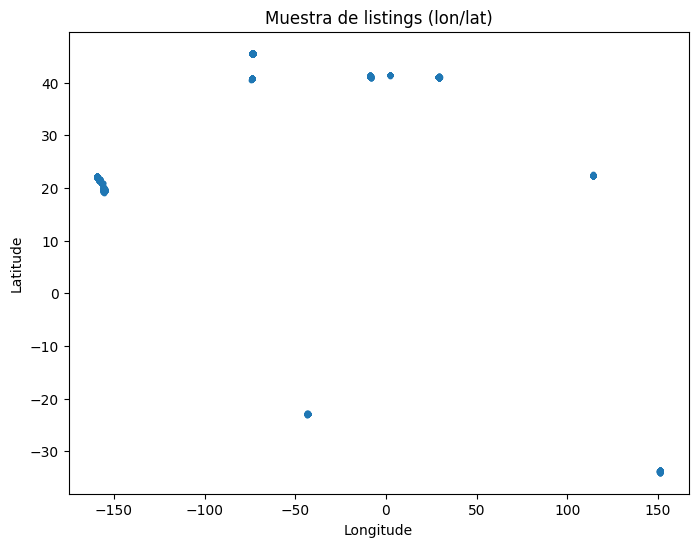

Puntos usados: 3000


In [21]:
import matplotlib.pyplot as plt

# 1. Definimos el pipeline para obtener coordenadas
pipeline = [
    # Filtramos documentos que tengan coordenadas válidas (no vacías)
    {"$match": {"address.location.coordinates": {"$ne": []}}},
    # Tomamos una muestra aleatoria de 3000 documentos
    {"$sample": {"size": 3000}},
    # Proyectamos solo las coordenadas
    {"$project": {
        "coords": "$address.location.coordinates",
        "_id": 0
    }}
]

# 2. Ejecutamos la consulta
df_geo = agg_df(pipeline)

# 3. Preparamos los datos para el gráfico
# MongoDB guarda las coordenadas geoespaciales como [Longitud, Latitud]
coords = np.array(df_geo["coords"].tolist())
lon = coords[:, 0]
lat = coords[:, 1]

# 4. Generamos el gráfico
plt.figure(figsize=(8, 6))
plt.scatter(lon, lat, s=10) # 's' es el tamaño del punto
plt.title("Muestra de listings (lon/lat)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 5. Imprimimos el texto final
print(f"Puntos usados: {len(df_geo)}")